## 1. Klasifikasi Flynn

Klasifikasi Flynn merupakan pengelompokan arsitektur komputer berdasarkan
jumlah instruksi dan jumlah data yang diproses.

Kategori Flynn terdiri dari:

- SISD (Single Instruction Single Data)
- SIMD (Single Instruction Multiple Data)
- MISD (Multiple Instruction Single Data)
- MIMD (Multiple Instruction Multiple Data)

### a. Operasi arr + arr pada NumPy Array

Kategori:
SIMD (Single Instruction Multiple Data)

Alasan:

Operasi penjumlahan array pada NumPy termasuk SIMD karena satu instruksi
operasi matematika diterapkan pada banyak elemen data secara bersamaan.

NumPy menggunakan vectorization sehingga proses pengolahan array dapat
dilakukan secara efisien tanpa melakukan perulangan satu per satu.
### b. Program Python biasa membaca file lalu memproses baris demi baris

Kategori:
SISD (Single Instruction Single Data)

Alasan:

Program Python tanpa threading maupun multiprocessing hanya menjalankan
satu instruksi terhadap satu data pada satu waktu.

Proses dilakukan secara sequential, yaitu membaca satu baris kemudian
memprosesnya sebelum melanjutkan ke baris berikutnya.
### c. Cluster komputer menjalankan simulasi cuaca berbeda

Kategori:
MIMD (Multiple Instruction Multiple Data)

Alasan:

Cluster komputer termasuk kategori MIMD karena setiap node pada cluster dapat
menjalankan instruksi yang berbeda terhadap data yang berbeda secara bersamaan.

Pada kasus simulasi cuaca, setiap node dapat melakukan perhitungan untuk
wilayah yang berbeda secara independen, misalnya satu node memproses data cuaca
Asia, node lain memproses data cuaca Eropa, dan node lainnya memproses data
cuaca Amerika.

Setiap node memiliki tugas, instruksi, dan kumpulan data masing-masing sehingga
proses dapat berjalan secara paralel tanpa harus menunggu node lainnya.
Karakteristik tersebut sesuai dengan konsep Multiple Instruction Multiple
Data (MIMD).

## 2. Analisis Hukum Amdahl

Hukum Amdahl digunakan untuk menghitung peningkatan performa program ketika sebagian proses dapat dijalankan secara paralel.

Rumus:

$$
Speedup(N)=\frac{1}{(1-P)+\frac{P}{N}}
$$

Dengan:

- P = proporsi program yang dapat diparalelkan
- N = jumlah processor

Diketahui:

$$
P=0.85
$$

Artinya 85% program dapat diproses secara paralel dan 15% tetap berjalan secara serial.

In [1]:
import pandas as pd

def amdahl_speedup(P, N):
    return 1 / ((1-P)+(P/N))


P = 0.85

N_values = [2,4,8,16,32,64]

speedup_values = []

for N in N_values:
    speedup = amdahl_speedup(P,N)
    speedup_values.append(round(speedup,3))


# Membuat tabel
tabel_speedup = pd.DataFrame({
    "Jumlah Processor (N)": N_values,
    "Speedup": speedup_values
})


tabel_speedup

,Jumlah Processor (N),Speedup
0,2,1.739
1,4,2.759
2,8,3.902
3,16,4.923
4,32,5.664
5,64,6.124


Berdasarkan hasil perhitungan, peningkatan jumlah processor menyebabkan
nilai speedup meningkat. Pada awal penambahan processor, peningkatan performa
terlihat cukup besar karena bagian program yang dapat diparalelkan masih
mendominasi.

Namun, peningkatan performa tidak bersifat linear karena masih terdapat bagian
program yang berjalan secara serial sebesar 15%. Bagian serial tersebut menjadi
batas peningkatan performa sehingga penambahan processor dalam jumlah besar
tidak selalu memberikan peningkatan speedup yang signifikan.

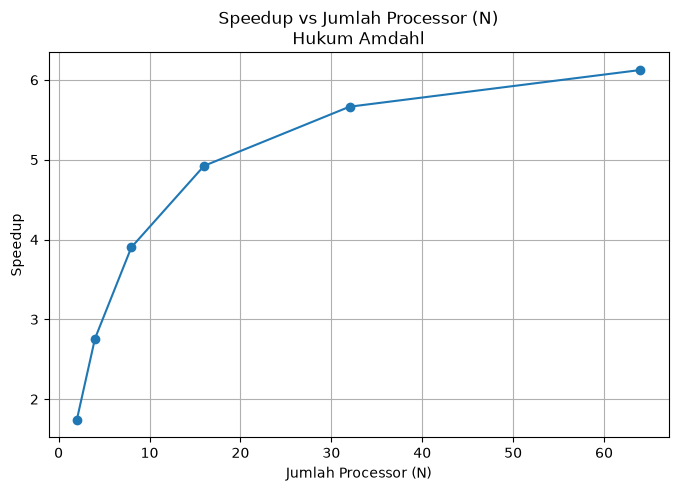

In [2]:
import matplotlib.pyplot as plt


# Data jumlah processor dan hasil speedup
N_values = [2,4,8,16,32,64]

speedup_values = [
    1.739,
    2.759,
    3.902,
    4.923,
    5.664,
    6.124
]
# Membuat plot
plt.figure(figsize=(8,5))

plt.plot(
    N_values,
    speedup_values,
    marker='o'
)

plt.xlabel("Jumlah Processor (N)")
plt.ylabel("Speedup")

plt.title("Speedup vs Jumlah Processor (N)\nHukum Amdahl")

plt.grid(True)

plt.show()

 Analisis Grafik Speedup vs N

Berdasarkan grafik hubungan antara jumlah processor (N) dan nilai speedup,
terlihat bahwa penambahan jumlah processor dapat meningkatkan performa
program.

Pada awal peningkatan processor, nilai speedup mengalami kenaikan yang cukup
signifikan. Hal ini terjadi karena sebagian besar proses dapat dijalankan
secara paralel sehingga tambahan processor memberikan keuntungan yang besar.

Namun, ketika jumlah processor semakin besar, peningkatan speedup mulai
melambat. Hal ini menunjukkan bahwa penambahan processor tidak memberikan
peningkatan performa secara linear.

Penyebabnya adalah masih terdapat bagian program yang berjalan secara serial
sebesar 15% yang tidak dapat dipercepat. Bagian serial tersebut menjadi
batas maksimum peningkatan performa sesuai dengan Hukum Amdahl.

## Analisis Diminishing Returns

Berdasarkan hasil perhitungan Hukum Amdahl, penambahan processor mulai
memberikan manfaat yang semakin kecil pada sekitar **N = 32 processor**.

Hal tersebut dapat dilihat dari perubahan nilai speedup:

- N = 16 menghasilkan speedup sebesar 4.923
- N = 32 menghasilkan speedup sebesar 5.664

Peningkatan speedup:
5.664 - 4.923 = 0.741


Sedangkan ketika processor ditambah dari N = 32 menjadi N = 64:

- N = 32 menghasilkan speedup sebesar 5.664
- N = 64 menghasilkan speedup sebesar 6.124

Peningkatan speedup:
6.124 - 5.664 = 0.460


Terlihat bahwa penambahan processor dari 32 menjadi 64 hanya memberikan
peningkatan performa yang kecil.

Hal ini terjadi karena dalam Hukum Amdahl masih terdapat bagian program yang
berjalan secara serial sebesar 15% (1-P). Bagian serial tersebut tidak dapat
dipercepat meskipun jumlah processor ditambah, sehingga semakin banyak
processor yang digunakan maka peningkatan performa semakin terbatas.

Fenomena ini disebut diminishing returns, yaitu kondisi ketika tambahan
sumber daya memberikan peningkatan hasil yang semakin kecil.## Analisis Diminishing Returns

Berdasarkan hasil perhitungan speedup dan grafik Hukum Amdahl, penambahan
processor mulai memberikan manfaat yang sangat kecil pada sekitar N = 32
processor.

Hal ini terlihat dari peningkatan speedup yang semakin kecil. Pada saat
processor ditingkatkan dari N = 16 menjadi N = 32, nilai speedup meningkat
dari 4.923 menjadi 5.664. Namun ketika processor ditambah lagi dari N = 32
menjadi N = 64, speedup hanya meningkat dari 5.664 menjadi 6.124.

Penurunan peningkatan performa tersebut terjadi karena masih terdapat bagian
program yang berjalan secara serial sebesar 15% (1-P). Bagian serial ini tidak
dapat dipercepat dengan penambahan processor sehingga semakin banyak processor
yang digunakan, manfaat tambahan yang diperoleh semakin kecil.

Fenomena ini disebut diminishing returns, yaitu kondisi ketika penambahan
sumber daya tidak lagi memberikan peningkatan performa yang sebanding.

## 3. Benchmark Fungsi CPU-bound


In [2]:
def hitung_prima(n):
    """Menghitung banyaknya bilangan prima dari 2 sampai n."""
    jumlah_prima = 0

    for angka in range(2, n + 1):
        prima = True

        for pembagi in range(2, int(math.sqrt(angka)) + 1):
            if angka % pembagi == 0:
                prima = False
                break

        if prima:
            jumlah_prima += 1

    return jumlah_prima

In [6]:
import time
import math
import pandas as pd

ukuran_input = [5000, 10000, 15000, 20000]
hasil_benchmark = []

for n in ukuran_input:
    mulai = time.perf_counter()
    hasil = hitung_prima(n)
    selesai = time.perf_counter()

    waktu = selesai - mulai
    hasil_benchmark.append({
        'Input n': n,
        'Jumlah Prima': hasil,
        'Waktu Eksekusi (detik)': waktu
    })

tabel_benchmark = pd.DataFrame(hasil_benchmark)
tabel_benchmark

,Input n,Jumlah Prima,Waktu Eksekusi (detik)
0,5000,669,0.003922
1,10000,1229,0.009503
2,15000,1754,0.017081
3,20000,2262,0.022235


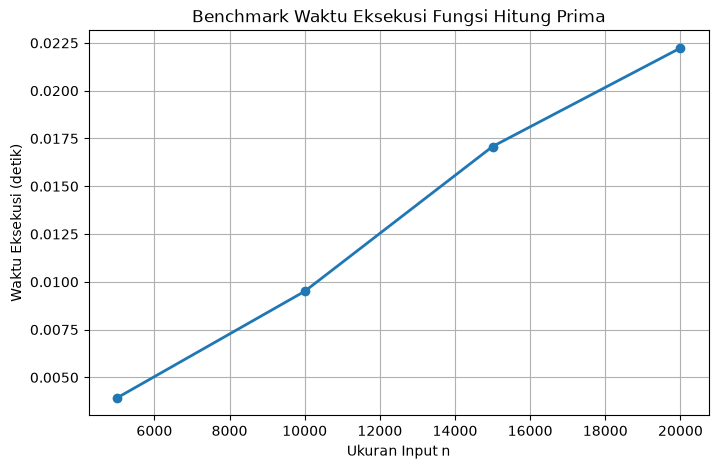

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    tabel_benchmark['Input n'],
    tabel_benchmark['Waktu Eksekusi (detik)'],
    marker='o',
    linewidth=2
)
plt.title('Benchmark Waktu Eksekusi Fungsi Hitung Prima')
plt.xlabel('Ukuran Input n')
plt.ylabel('Waktu Eksekusi (detik)')
plt.grid(True)
plt.show()

## **4. Refleksi Singkat**

Hukum Amdahl lebih relevan digunakan ketika ukuran masalah tetap dan fokus analisis adalah seberapa besar peningkatan performa yang diperoleh dari penambahan processor. Hukum ini menekankan bahwa bagian program yang berjalan secara serial menjadi batas utama speedup, sehingga penambahan processor tidak selalu menghasilkan peningkatan performa yang sebanding. Contoh penerapannya adalah proses pengolahan citra dengan ukuran gambar tetap, di mana beberapa proses seperti input dan penyimpanan data tetap berjalan secara serial.

Berbeda dengan Amdahl, Hukum Gustafson lebih sesuai ketika ukuran masalah dapat diperbesar mengikuti peningkatan jumlah processor. Hukum ini menunjukkan bahwa sistem paralel dapat menyelesaikan masalah yang lebih besar dengan waktu yang relatif sama. Contohnya adalah simulasi cuaca pada superkomputer, ketika penambahan node memungkinkan peningkatan resolusi wilayah dan jumlah data yang dianalisis.